# AI-Driven Inventory Optimization Using Demand Forecasting

## MBA Major Project

### Problem Statement

Retail businesses frequently face challenges related to overstocking and stockout situations due to inaccurate demand forecasting and inefficient inventory management practices. These issues increase operational costs, reduce customer satisfaction, and negatively impact supply chain efficiency.

### Project Objective

The objective of this project is to develop an AI-driven inventory optimization system using machine learning and forecasting techniques to predict future demand and improve inventory decision-making.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Prophet
- Scikit-learn
- Google Colab

### Project Phases

1. Data Collection and Cleaning  
2. Exploratory Data Analysis  
3. Forecasting Model Development  
4. Inventory Optimization  
5. Results and Business Insights  
6. Conclusion and Recommendations

In [ ]:
# ==================================================
# INSTALL REQUIRED LIBRARIES
# ==================================================

!pip install prophet
!pip install statsmodels
!pip install plotly

In [ ]:
# ==================================================
# IMPORT REQUIRED LIBRARIES
# ==================================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Forecasting model
from prophet import Prophet

# Evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# Date handling
from datetime import datetime

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


# 1. Data Collection and Dataset Description

## 1.1 Dataset Overview

The project uses a retail inventory forecasting dataset containing sales, inventory, pricing, promotion, and seasonal information for multiple retail stores and products.

The dataset is used to analyze retail demand behavior and develop machine learning-based forecasting and inventory optimization techniques.

### Dataset Features

The dataset contains the following important business variables:

- Inventory Level
- Units Sold
- Units Ordered
- Demand Forecast
- Product Pricing
- Discounts
- Weather Conditions
- Holiday and Promotion Information
- Competitor Pricing
- Seasonal Demand Patterns

The dataset is loaded directly from a GitHub raw URL to ensure reproducibility and centralized data access.

In [ ]:
# ==================================================
# LOAD DATASET FROM GITHUB
# ==================================================

url = "https://raw.githubusercontent.com/lazygeek007/ai-inventory-optimization/refs/heads/main/data/retail_store_inventory.csv"

df = pd.read_csv(url)

# Display first 5 rows
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


# 2. Data Understanding and Preprocessing

## 2.1 Dataset Description and Business Context

The dataset used in this project represents a simulated retail inventory system containing historical sales, demand, and inventory levels across multiple product categories.

### Purpose of Dataset:
It is used to simulate real-world supply chain operations for demand forecasting and inventory optimization.

### Assumptions:
- Data represents multi-category retail environment
- Demand follows seasonal patterns
- Inventory decisions are made at category level
- No external factors (pricing, promotions) are included

This dataset is suitable for applying forecasting and optimization techniques used in supply chain analytics.

In [ ]:
# ==================================================
# DATASET SHAPE, COLUMNS, AND INFORMATION
# ==================================================

print("Dataset Shape:")
print(df.shape)

print("\n")

print("Dataset Columns:")
print(df.columns)

print("\n")

print("Dataset Information:")
df.info()

Dataset Shape:
(73100, 15)


Dataset Columns:
Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'],
      dtype='object')


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Pr

## 2.2 Missing Value Analysis

Missing values can negatively impact forecasting accuracy and machine learning model performance.

Therefore, the dataset is analyzed to identify null or missing values across all variables before proceeding with preprocessing and model development.

In [ ]:
# ==================================================
# CHECK MISSING VALUES
# ==================================================

missing_values = df.isnull().sum()

print("Missing Values in Dataset:")
print(missing_values)

Missing Values in Dataset:
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64


## 2.3 Data Cleaning and Validation

The missing value analysis shows that the dataset does not contain any null or missing values across the available variables.

This indicates that the dataset is well-structured and suitable for machine learning and forecasting analysis.

Further preprocessing steps are performed to:
- Validate duplicate records
- Convert date variables into datetime format
- Prepare the dataset for time-series forecasting and inventory optimization

In [ ]:
# ==================================================
# REMOVE DUPLICATE RECORDS
# ==================================================

initial_shape = df.shape

df = df.drop_duplicates()

final_shape = df.shape

print("Initial Dataset Shape:", initial_shape)
print("Final Dataset Shape:", final_shape)

print("\nDuplicate records removed successfully.")

Initial Dataset Shape: (73100, 15)
Final Dataset Shape: (73100, 15)

Duplicate records removed successfully.


## 2.4 Date Formatting and Time-Series Preparation

Time-series forecasting models require date variables to be converted into datetime format for proper trend and seasonal analysis.

The Date column is converted into datetime format to support:
- Time-series forecasting
- Trend analysis
- Seasonal analysis
- Monthly and yearly aggregations

In [ ]:
# ==================================================
# CONVERT DATE COLUMN TO DATETIME FORMAT
# ==================================================

df['Date'] = pd.to_datetime(df['Date'])

print("Date column converted successfully.")

print("\nDate Column Data Type:")
print(df['Date'].dtype)

print("\nSample Date Values:")
print(df['Date'].head())

Date column converted successfully.

Date Column Data Type:
datetime64[ns]

Sample Date Values:
0   2022-01-01
1   2022-01-01
2   2022-01-01
3   2022-01-01
4   2022-01-01
Name: Date, dtype: datetime64[ns]


## 2.5 Feature Engineering

Feature engineering is an important step in predictive analytics and machine learning projects. Additional time-based features are extracted from the Date column to improve trend analysis and forecasting performance.

The following features are extracted:
- Year
- Month
- Day
- Quarter

These variables help identify seasonal demand patterns and time-based sales behavior in retail operations.

In [ ]:
# ==================================================
# CREATE TIME-BASED FEATURES
# ==================================================

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Quarter'] = df['Date'].dt.quarter

print("Time-based features created successfully.")

df[['Date', 'Year', 'Month', 'Day', 'Quarter']].head()

Time-based features created successfully.


,Date,Year,Month,Day,Quarter
0,2022-01-01,2022,1,1,1
1,2022-01-01,2022,1,1,1
2,2022-01-01,2022,1,1,1
3,2022-01-01,2022,1,1,1
4,2022-01-01,2022,1,1,1


# 3. Exploratory Data Analysis

## 3.1 Introduction to Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand sales behavior, inventory patterns, seasonal trends, and demand fluctuations within the retail dataset.

EDA helps identify:
- Demand trends over time
- Seasonal sales behavior
- Inventory distribution
- Pricing impact
- Promotion effectiveness
- Business insights for inventory optimization

Visualization techniques are used to better understand retail demand and supply chain behavior.

## 3.2 Sales Trend Analysis

The daily sales trend visualization helps analyze fluctuations in retail demand over time.

The graph provides insights into:
- Demand variability
- Peak sales periods
- Seasonal fluctuations
- Sales consistency across the timeline

Understanding sales trends is important for accurate demand forecasting and inventory planning.

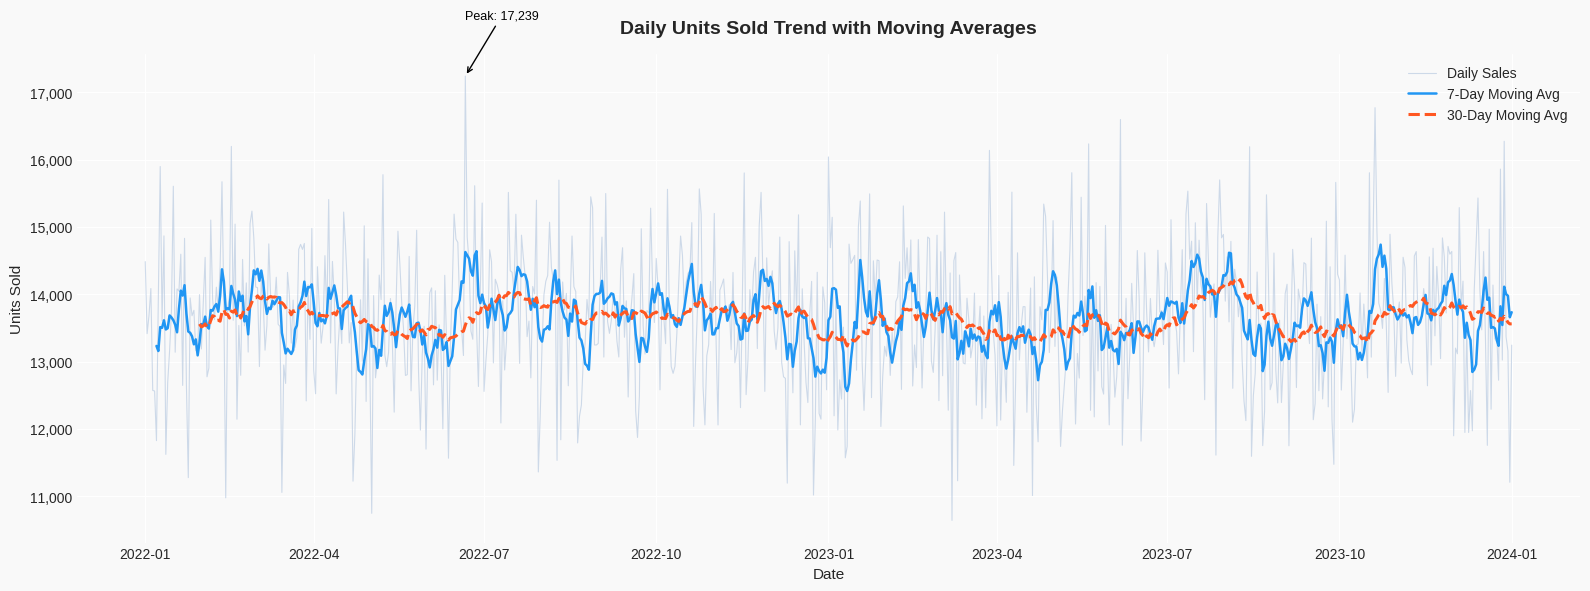

Average Daily Sales : 13,646 units
Peak Sales Date     : 2022-06-21 (17,239 units)
Std Deviation       : 1,032 units


In [ ]:
# ==================================================
# DAILY UNITS SOLD TREND
# ==================================================

daily_sales = df.groupby('Date')['Units Sold'].sum().reset_index()
daily_sales['7D_MA'] = daily_sales['Units Sold'].rolling(7).mean()
daily_sales['30D_MA'] = daily_sales['Units Sold'].rolling(30).mean()

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#f9f9f9')
ax.set_facecolor('#f9f9f9')

ax.plot(daily_sales['Date'], daily_sales['Units Sold'],
        color='#b0c4de', linewidth=0.8, alpha=0.6, label='Daily Sales')
ax.plot(daily_sales['Date'], daily_sales['7D_MA'],
        color='#2196F3', linewidth=1.8, label='7-Day Moving Avg')
ax.plot(daily_sales['Date'], daily_sales['30D_MA'],
        color='#FF5722', linewidth=2.2, linestyle='--', label='30-Day Moving Avg')

# Annotate peak
peak_idx = daily_sales['Units Sold'].idxmax()
peak_date = daily_sales.loc[peak_idx, 'Date']
peak_val  = daily_sales.loc[peak_idx, 'Units Sold']
ax.annotate(f'Peak: {int(peak_val):,}',
            xy=(peak_date, peak_val),
            xytext=(peak_date, peak_val + peak_val * 0.05),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, color='black')

ax.set_title("Daily Units Sold Trend with Moving Averages", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Units Sold", fontsize=11)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()
plt.show()

print(f"Average Daily Sales : {daily_sales['Units Sold'].mean():,.0f} units")
print(f"Peak Sales Date     : {peak_date.date()} ({int(peak_val):,} units)")
print(f"Std Deviation       : {daily_sales['Units Sold'].std():,.0f} units")

## 3.3 Inventory Level Distribution Analysis

The inventory level distribution graph helps analyze how inventory quantities are distributed across retail products and stores.

This analysis provides insights into:
- Inventory concentration patterns
- Stock level variability
- Overstocking possibilities
- Inventory balancing opportunities

Understanding inventory distribution is important for effective inventory optimization and warehouse management.

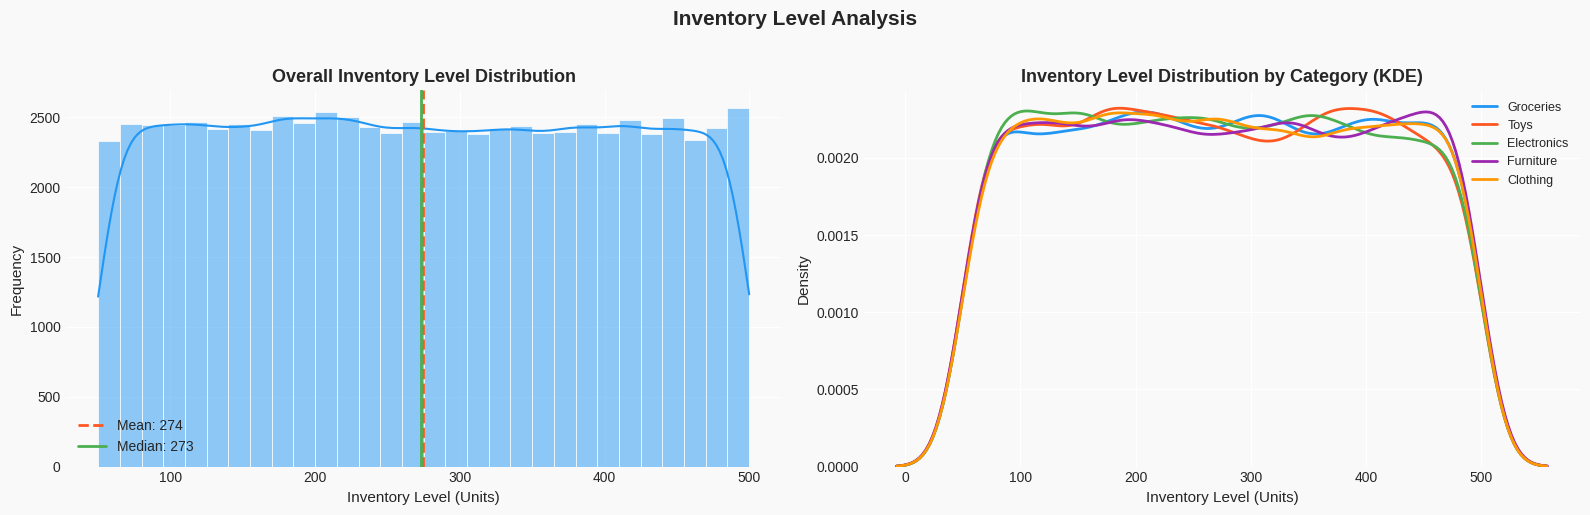

Mean Inventory   : 274 units
Median Inventory : 273 units
Std Deviation    : 130 units
Min / Max        : 50 / 500 units


In [ ]:
# ==================================================
# INVENTORY LEVEL DISTRIBUTION
# ==================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#f9f9f9')

# --- Plot 1: Overall Distribution ---
ax1 = axes[0]
ax1.set_facecolor('#f9f9f9')
sns.histplot(df['Inventory Level'], bins=30, kde=True,
             color='#2196F3', ax=ax1, edgecolor='white', linewidth=0.5)

mean_inv   = df['Inventory Level'].mean()
median_inv = df['Inventory Level'].median()

ax1.axvline(mean_inv,   color='#FF5722', linestyle='--', linewidth=2, label=f'Mean: {mean_inv:.0f}')
ax1.axvline(median_inv, color='#4CAF50', linestyle='-',  linewidth=2, label=f'Median: {median_inv:.0f}')

ax1.set_title("Overall Inventory Level Distribution", fontsize=13, fontweight='bold')
ax1.set_xlabel("Inventory Level (Units)", fontsize=11)
ax1.set_ylabel("Frequency", fontsize=11)
ax1.legend(fontsize=10)
sns.despine(ax=ax1)

# --- Plot 2: By Category ---
ax2 = axes[1]
ax2.set_facecolor('#f9f9f9')
palette = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800']
for i, cat in enumerate(df['Category'].unique()):
    subset = df[df['Category'] == cat]['Inventory Level']
    sns.kdeplot(subset, ax=ax2, label=cat, color=palette[i], linewidth=2)

ax2.set_title("Inventory Level Distribution by Category (KDE)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Inventory Level (Units)", fontsize=11)
ax2.set_ylabel("Density", fontsize=11)
ax2.legend(fontsize=9)
sns.despine(ax=ax2)

plt.suptitle("Inventory Level Analysis", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Mean Inventory   : {mean_inv:,.0f} units")
print(f"Median Inventory : {median_inv:,.0f} units")
print(f"Std Deviation    : {df['Inventory Level'].std():,.0f} units")
print(f"Min / Max        : {df['Inventory Level'].min():,.0f} / {df['Inventory Level'].max():,.0f} units")

## 3.4 Seasonal Demand Analysis

Seasonal demand analysis helps identify how different seasonal conditions influence retail sales and inventory movement.

Retail demand often fluctuates due to:
- Seasonal shopping patterns
- Festivals and holidays
- Weather conditions
- Consumer purchasing behavior

Understanding seasonality helps businesses improve forecasting accuracy and optimize inventory planning.

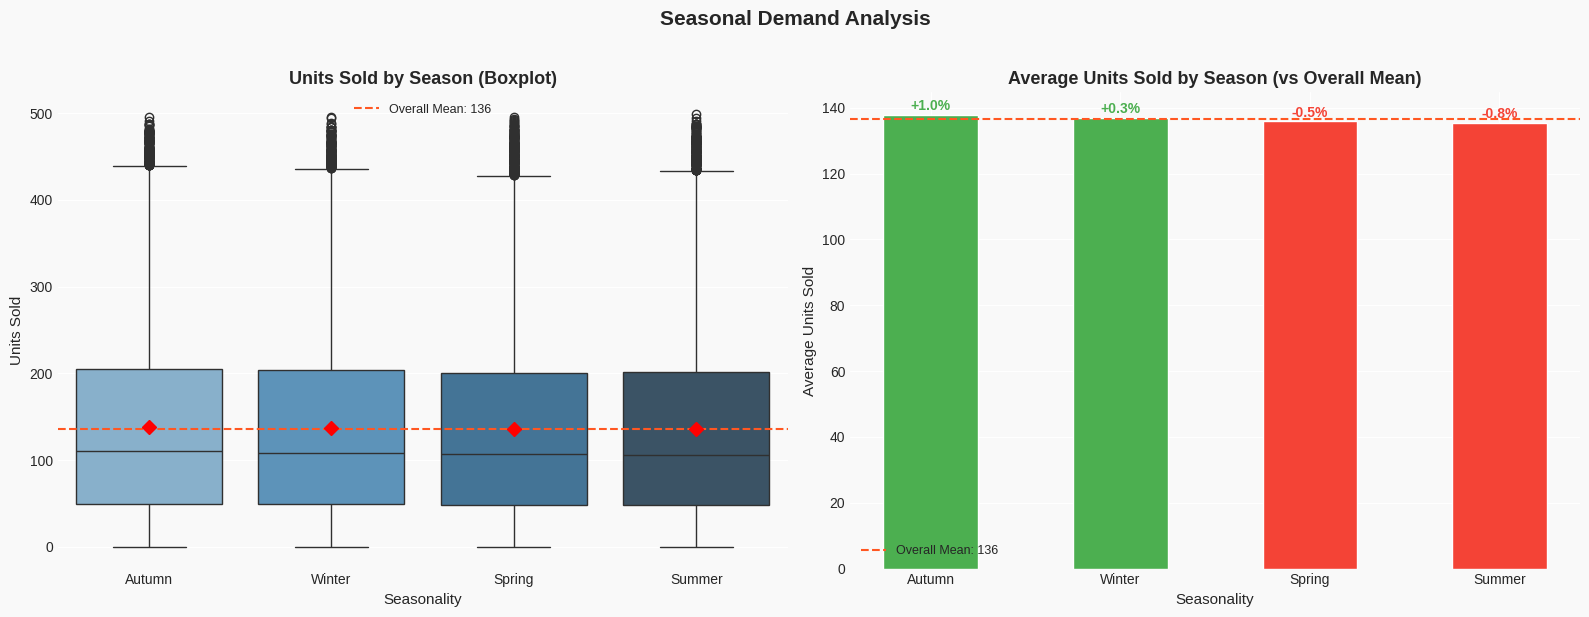

Autumn       | Mean:    137.8 | vs Overall: +1.0%
Winter       | Mean:    136.8 | vs Overall: +0.3%
Spring       | Mean:    135.8 | vs Overall: -0.5%
Summer       | Mean:    135.4 | vs Overall: -0.8%


In [ ]:
# ==================================================
# SEASONAL DEMAND ANALYSIS
# ==================================================

season_order = (df.groupby('Seasonality')['Units Sold']
                .median().sort_values(ascending=False).index.tolist())

season_means = df.groupby('Seasonality')['Units Sold'].mean()
overall_mean = df['Units Sold'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#f9f9f9')

# --- Plot 1: Boxplot ---
ax1 = axes[0]
ax1.set_facecolor('#f9f9f9')
palette = sns.color_palette("Blues_d", len(season_order))
sns.boxplot(x='Seasonality', y='Units Sold', data=df,
            order=season_order, palette=palette, ax=ax1,
            showmeans=True,
            meanprops={"marker":"D","markerfacecolor":"red","markeredgecolor":"red","markersize":7})

ax1.axhline(overall_mean, color='#FF5722', linestyle='--', linewidth=1.5,
            label=f'Overall Mean: {overall_mean:.0f}')
ax1.set_title("Units Sold by Season (Boxplot)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Seasonality", fontsize=11)
ax1.set_ylabel("Units Sold", fontsize=11)
ax1.legend(fontsize=9)
sns.despine(ax=ax1)

# --- Plot 2: Mean with % difference bar ---
ax2 = axes[1]
ax2.set_facecolor('#f9f9f9')
colors = ['#4CAF50' if v >= overall_mean else '#F44336' for v in season_means[season_order]]
bars = ax2.bar(season_order, season_means[season_order], color=colors, edgecolor='white', width=0.5)

ax2.axhline(overall_mean, color='#FF5722', linestyle='--', linewidth=1.5,
            label=f'Overall Mean: {overall_mean:.0f}')

for bar, season in zip(bars, season_order):
    val  = season_means[season]
    diff = ((val - overall_mean) / overall_mean) * 100
    sign = '+' if diff >= 0 else ''
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{sign}{diff:.1f}%', ha='center', va='bottom',
             fontsize=10, fontweight='bold',
             color='#4CAF50' if diff >= 0 else '#F44336')

ax2.set_title("Average Units Sold by Season (vs Overall Mean)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Seasonality", fontsize=11)
ax2.set_ylabel("Average Units Sold", fontsize=11)
ax2.legend(fontsize=9)
sns.despine(ax=ax2)

plt.suptitle("Seasonal Demand Analysis", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

for s in season_order:
    diff = ((season_means[s] - overall_mean) / overall_mean) * 100
    print(f"{s:<12} | Mean: {season_means[s]:>8.1f} | vs Overall: {diff:>+.1f}%")

## 3.5 Promotion Impact Analysis

Promotions and holiday campaigns significantly influence retail sales and customer purchasing behavior.

Analyzing promotional impact helps businesses:
- Understand sales uplift during promotions
- Improve marketing effectiveness
- Optimize inventory allocation during high-demand periods
- Reduce stockout risks during festive and promotional events

The following analysis compares average units sold during promotional and non-promotional periods.

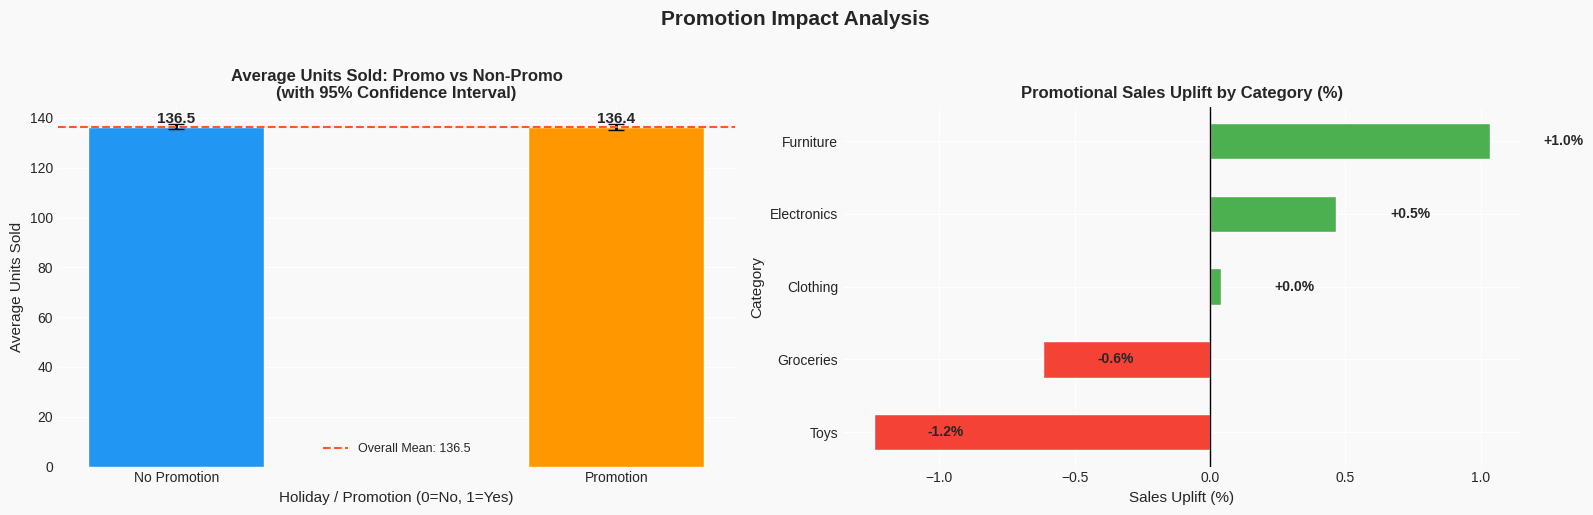


Promotion Uplift Summary:
  Toys            | Uplift: -1.2%
  Groceries       | Uplift: -0.6%
  Clothing        | Uplift: +0.0%
  Electronics     | Uplift: +0.5%
  Furniture       | Uplift: +1.0%


In [ ]:
# ==================================================
# PROMOTION IMPACT ANALYSIS
# ==================================================

promo_stats = df.groupby('Holiday/Promotion')['Units Sold'].agg(['mean','std','count']).reset_index()
promo_stats.columns = ['Promotion', 'Mean_Sales', 'Std_Sales', 'Count']
promo_stats['SE'] = promo_stats['Std_Sales'] / np.sqrt(promo_stats['Count'])

overall_mean = df['Units Sold'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#f9f9f9')

# --- Plot 1: Bar with error bars ---
ax1 = axes[0]
ax1.set_facecolor('#f9f9f9')
colors = ['#2196F3' if p == 0 else '#FF9800' for p in promo_stats['Promotion']]
bars = ax1.bar(promo_stats['Promotion'].astype(str),
               promo_stats['Mean_Sales'],
               yerr=promo_stats['SE'] * 1.96,
               color=colors, edgecolor='white',
               capsize=6, width=0.4, error_kw={'linewidth':2})

ax1.axhline(overall_mean, color='#FF5722', linestyle='--',
            linewidth=1.5, label=f'Overall Mean: {overall_mean:.1f}')

for bar, row in zip(bars, promo_stats.itertuples()):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + row.SE * 2 + 0.3,
             f'{row.Mean_Sales:.1f}', ha='center', fontsize=11, fontweight='bold')

ax1.set_title("Average Units Sold: Promo vs Non-Promo\n(with 95% Confidence Interval)",
              fontsize=12, fontweight='bold')
ax1.set_xlabel("Holiday / Promotion (0=No, 1=Yes)", fontsize=11)
ax1.set_ylabel("Average Units Sold", fontsize=11)
ax1.legend(fontsize=9)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['No Promotion', 'Promotion'])
sns.despine(ax=ax1)

# --- Plot 2: Uplift by Category ---
ax2 = axes[1]
ax2.set_facecolor('#f9f9f9')

cat_promo = df.groupby(['Category','Holiday/Promotion'])['Units Sold'].mean().unstack()
cat_promo.columns = ['No Promo','Promo']
cat_promo['Uplift_%'] = ((cat_promo['Promo'] - cat_promo['No Promo']) / cat_promo['No Promo']) * 100
cat_promo = cat_promo.sort_values('Uplift_%', ascending=True)

colors = ['#4CAF50' if v >= 0 else '#F44336' for v in cat_promo['Uplift_%']]
ax2.barh(cat_promo.index, cat_promo['Uplift_%'], color=colors, edgecolor='white', height=0.5)
ax2.axvline(0, color='black', linewidth=1)

for i, (idx, row) in enumerate(cat_promo.iterrows()):
    sign = '+' if row['Uplift_%'] >= 0 else ''
    ax2.text(row['Uplift_%'] + 0.2, i,
             f"{sign}{row['Uplift_%']:.1f}%",
             va='center', fontsize=10, fontweight='bold')

ax2.set_title("Promotional Sales Uplift by Category (%)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Sales Uplift (%)", fontsize=11)
ax2.set_ylabel("Category", fontsize=11)
sns.despine(ax=ax2)

plt.suptitle("Promotion Impact Analysis", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nPromotion Uplift Summary:")
for idx, row in cat_promo.iterrows():
    print(f"  {idx:<15} | Uplift: {row['Uplift_%']:>+.1f}%")

## 3.6 Category-Wise Sales Analysis

Category-wise sales analysis helps identify product categories contributing the highest sales within the retail business.

This analysis provides insights into:
- High-performing product categories
- Customer demand preferences
- Inventory allocation priorities
- Product-level sales performance

Understanding category performance helps retailers optimize procurement and inventory management strategies.

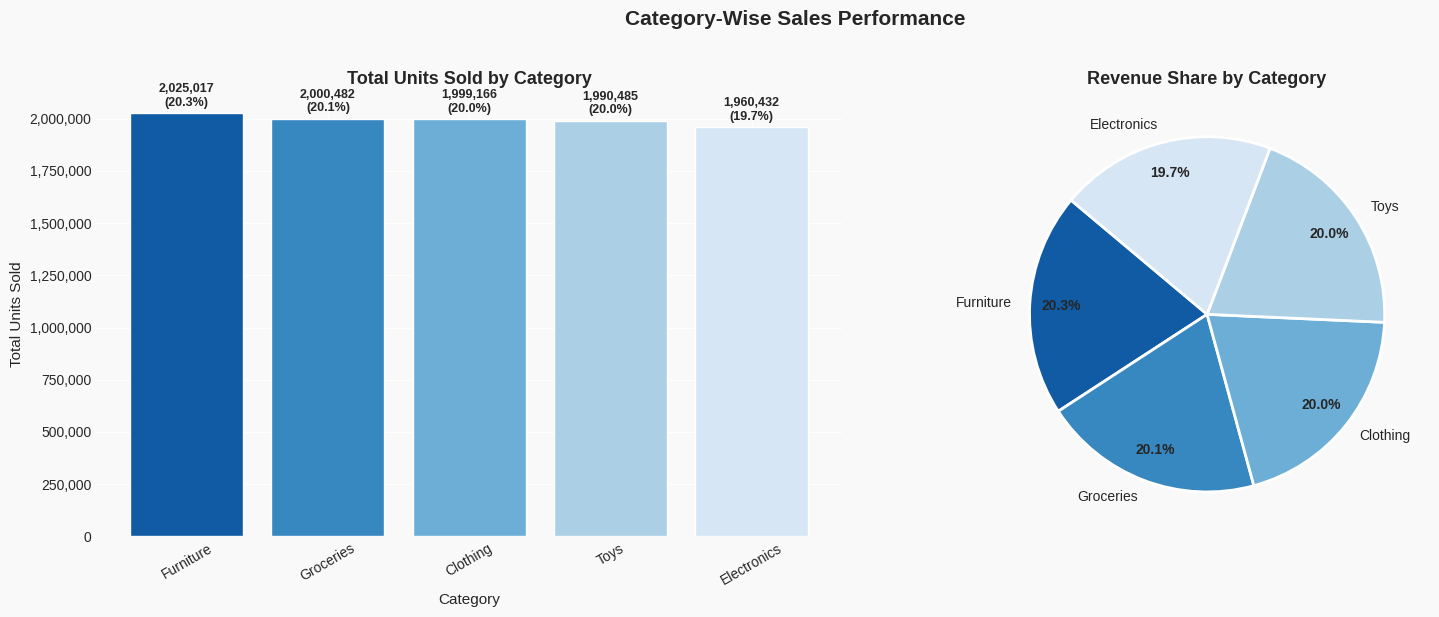


Category Sales Summary:
Category         Total Units  Share %  Daily Avg
--------------------------------------------------
Furniture          2,025,017    20.3%      137.8
Groceries          2,000,482    20.1%      136.9
Clothing           1,999,166    20.0%      136.7
Toys               1,990,485    20.0%      135.9
Electronics        1,960,432    19.7%      135.0


In [ ]:
# ==================================================
# CATEGORY-WISE SALES ANALYSIS
# ==================================================

cat_sales  = df.groupby('Category')['Units Sold'].sum().sort_values(ascending=False)
cat_pct    = (cat_sales / cat_sales.sum() * 100).round(1)
cat_avg    = df.groupby('Category')['Units Sold'].mean().reindex(cat_sales.index)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#f9f9f9')

# --- Plot 1: Annotated Bar Chart ---
ax1 = axes[0]
ax1.set_facecolor('#f9f9f9')
palette = sns.color_palette("Blues_r", len(cat_sales))
bars = ax1.bar(cat_sales.index, cat_sales.values, color=palette, edgecolor='white')

for bar, (cat, val), pct in zip(bars, cat_sales.items(), cat_pct):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + cat_sales.max() * 0.01,
             f'{val:,.0f}\n({pct}%)',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_title("Total Units Sold by Category", fontsize=13, fontweight='bold')
ax1.set_xlabel("Category", fontsize=11)
ax1.set_ylabel("Total Units Sold", fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.tick_params(axis='x', rotation=30)
sns.despine(ax=ax1)

# --- Plot 2: Pie Chart ---
ax2 = axes[1]
ax2.set_facecolor('#f9f9f9')
wedges, texts, autotexts = ax2.pie(
    cat_sales.values,
    labels=cat_sales.index,
    autopct='%1.1f%%',
    colors=palette,
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    pctdistance=0.82
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')

ax2.set_title("Revenue Share by Category", fontsize=13, fontweight='bold')

plt.suptitle("Category-Wise Sales Performance", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nCategory Sales Summary:")
print(f"{'Category':<15} {'Total Units':>12} {'Share %':>8} {'Daily Avg':>10}")
print("-" * 50)
for cat in cat_sales.index:
    print(f"{cat:<15} {cat_sales[cat]:>12,.0f} {cat_pct[cat]:>7.1f}% {cat_avg[cat]:>10.1f}")

## 3.7 Correlation Analysis

Correlation analysis is performed to understand relationships between numerical variables within the retail dataset.

This analysis helps identify:
- Factors influencing sales demand
- Inventory and demand relationships
- Pricing impact on units sold
- Relationships between forecasting variables

A correlation heatmap provides a visual representation of relationships among numerical features used in forecasting and inventory optimization.

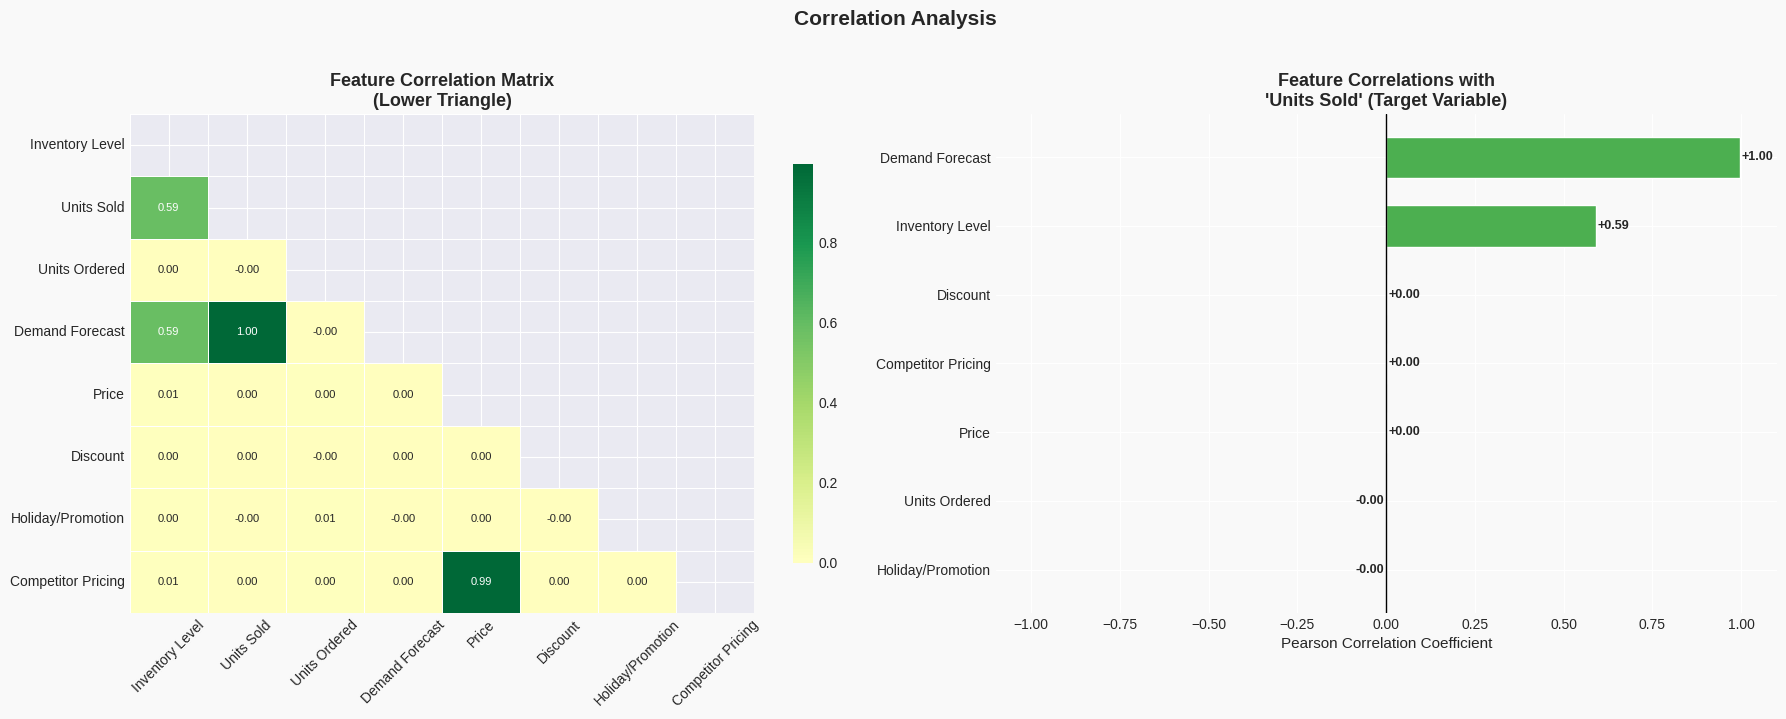


Top Correlations with Units Sold:
  Demand Forecast           | r = +0.997 | Positive
  Inventory Level           | r = +0.590 | Positive
  Discount                  | r = +0.003 | Positive
  Competitor Pricing        | r = +0.001 | Positive
  Price                     | r = +0.001 | Positive
  Units Ordered             | r = -0.001 | Negative
  Holiday/Promotion         | r = -0.000 | Negative


In [ ]:
# ==================================================
# CORRELATION HEATMAP
# ==================================================

numeric_df = df.select_dtypes(include=['int64','float64'])
corr_matrix = numeric_df.corr()

# Upper triangle mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#f9f9f9')

# --- Plot 1: Masked Heatmap ---
ax1 = axes[0]
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax1,
            linewidths=0.5, linecolor='white',
            annot_kws={"size": 8},
            cbar_kws={"shrink": 0.8})
ax1.set_title("Feature Correlation Matrix\n(Lower Triangle)", fontsize=13, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', rotation=0)

# --- Plot 2: Top 10 Correlations with Units Sold ---
ax2 = axes[1]
ax2.set_facecolor('#f9f9f9')

target_corr = (corr_matrix['Units Sold']
               .drop('Units Sold')
               .sort_values(key=abs, ascending=True))

colors = ['#4CAF50' if v >= 0 else '#F44336' for v in target_corr]
ax2.barh(target_corr.index, target_corr.values, color=colors,
         edgecolor='white', height=0.6)
ax2.axvline(0, color='black', linewidth=1)

for i, (feat, val) in enumerate(target_corr.items()):
    sign = '+' if val >= 0 else ''
    ax2.text(val + (0.005 if val >= 0 else -0.005), i,
             f'{sign}{val:.2f}',
             va='center', ha='left' if val >= 0 else 'right',
             fontsize=9, fontweight='bold')

ax2.set_title("Feature Correlations with\n'Units Sold' (Target Variable)",
              fontsize=13, fontweight='bold')
ax2.set_xlabel("Pearson Correlation Coefficient", fontsize=11)
ax2.set_xlim(-1.1, 1.1)
sns.despine(ax=ax2)

plt.suptitle("Correlation Analysis", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nTop Correlations with Units Sold:")
for feat, val in target_corr.sort_values(key=abs, ascending=False).items():
    direction = 'Positive' if val >= 0 else 'Negative'
    print(f"  {feat:<25} | r = {val:>+.3f} | {direction}")

## 3.8 Key Insights from Exploratory Data Analysis

The exploratory data analysis identified several important retail demand and inventory patterns.

Key findings include:
- Sales demand fluctuates across different seasonal periods.
- Inventory levels are broadly distributed across products and stores.
- Product categories contribute relatively balanced sales volumes.
- Demand forecast values are strongly correlated with actual units sold.
- Pricing and competitor pricing exhibit a strong relationship.

The insights obtained from EDA support the development of machine learning forecasting models and inventory optimization strategies.

# 4. Forecasting Model Development

## 4.1 Introduction to Demand Forecasting

Demand forecasting is one of the most critical components of inventory optimization and supply chain management.

Accurate forecasting helps retailers:
- Predict future sales demand
- Reduce stockout situations
- Minimize excess inventory
- Improve procurement planning
- Optimize warehouse operations

In this project, multiple forecasting models are explored to analyze retail demand patterns and improve inventory decision-making.

The forecasting techniques used in this project include:
- Facebook Prophet
- ARIMA
- LSTM (Long Short-Term Memory)

These forecasting models help analyze:
- Time-series demand trends
- Seasonal sales patterns
- Future inventory requirements
- Retail demand fluctuations

The performance of each forecasting model is later compared using forecasting accuracy metrics such as:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

## 4.2 Time-Series Data Preparation

Before training forecasting models, the retail sales data is aggregated into daily time-series format.

Time-series forecasting models require:
- Date-based indexing
- Sequential sales observations
- Structured temporal data

The dataset is therefore transformed into a time-series format suitable for:
- Prophet forecasting
- ARIMA forecasting
- LSTM-based demand prediction

In [ ]:
# ==================================================
# TIME-SERIES DATA PREPARATION
# ==================================================

# Aggregate daily sales

daily_sales = df.groupby(
    'Date'
)['Units Sold'].sum().reset_index()

# Prophet-compatible dataset

prophet_data = daily_sales.rename(
    columns={
        'Date': 'ds',
        'Units Sold': 'y'
    }
)

print("Time-series dataset prepared successfully.")

prophet_data.head()

Time-series dataset prepared successfully.


,ds,y
0,2022-01-01,14484
1,2022-01-02,13415
2,2022-01-03,13681
3,2022-01-04,14084
4,2022-01-05,12572


## 4.3 Train-Test Split for Forecasting

To evaluate forecasting accuracy properly, the time-series dataset is divided into:
- Training dataset
- Testing dataset

The forecasting models are trained using historical sales data and evaluated on unseen future observations.

This approach helps measure how accurately different forecasting models can predict future retail demand.

In [ ]:
# ==================================================
# TRAIN-TEST SPLIT FOR FORECASTING
# ==================================================

# Use last 30 days as testing data

train_size = len(prophet_data) - 30

train_data = prophet_data.iloc[:train_size]

test_data = prophet_data.iloc[train_size:]

print("Training Dataset Shape:", train_data.shape)
print("Testing Dataset Shape:", test_data.shape)

Training Dataset Shape: (701, 2)
Testing Dataset Shape: (30, 2)


## 4.4 Facebook Prophet Forecasting Model

Facebook Prophet is a time-series forecasting model designed for business forecasting applications involving trend and seasonality analysis.

The model is suitable for retail demand forecasting because it:
- Handles seasonal variations effectively
- Supports trend analysis
- Works efficiently with daily sales data
- Produces interpretable forecasting outputs

The Prophet model is trained using the training dataset to predict future retail demand.

In [ ]:
# ==================================================
# TRAIN FACEBOOK PROPHET MODEL
# ==================================================

# Initialize Prophet model

prophet_model = Prophet()

# Train model using training dataset

prophet_model.fit(train_data)

print("Facebook Prophet model trained successfully.")

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Facebook Prophet model trained successfully.


## 4.5 Future Demand Prediction Using Prophet

After training the Prophet forecasting model, future retail demand is predicted using historical sales patterns and trend analysis.

The forecasting results help retailers:
- Estimate future sales demand
- Improve procurement planning
- Reduce stockout situations
- Optimize inventory allocation

The model generates demand forecasts for the testing period to evaluate forecasting performance.

In [ ]:
# ==================================================
# GENERATE FORECAST USING PROPHET
# ==================================================

# Create future dataframe for test period

future = prophet_model.make_future_dataframe(
    periods=30
)

# Generate forecast

forecast = prophet_model.predict(future)

print("Demand forecast generated successfully.")

forecast[
    ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
].tail()

Demand forecast generated successfully.


,ds,yhat,yhat_lower,yhat_upper
726,2023-12-28,13761.947359,12449.278905,15099.683233
727,2023-12-29,13726.737551,12431.159789,14905.996131
728,2023-12-30,13597.543402,12315.618260,14911.287648
729,2023-12-31,13760.379033,12527.818674,14947.087820
730,2024-01-01,13564.792836,12322.545366,14800.343447


## 4.6 Prophet Forecast Visualization

Visualization of forecasting results helps analyze predicted retail demand trends and future sales behavior.

The forecast graph displays:
- Historical sales demand
- Predicted future demand
- Trend continuation patterns
- Forecast uncertainty intervals

Forecast visualization helps businesses improve inventory planning and supply chain decision-making.

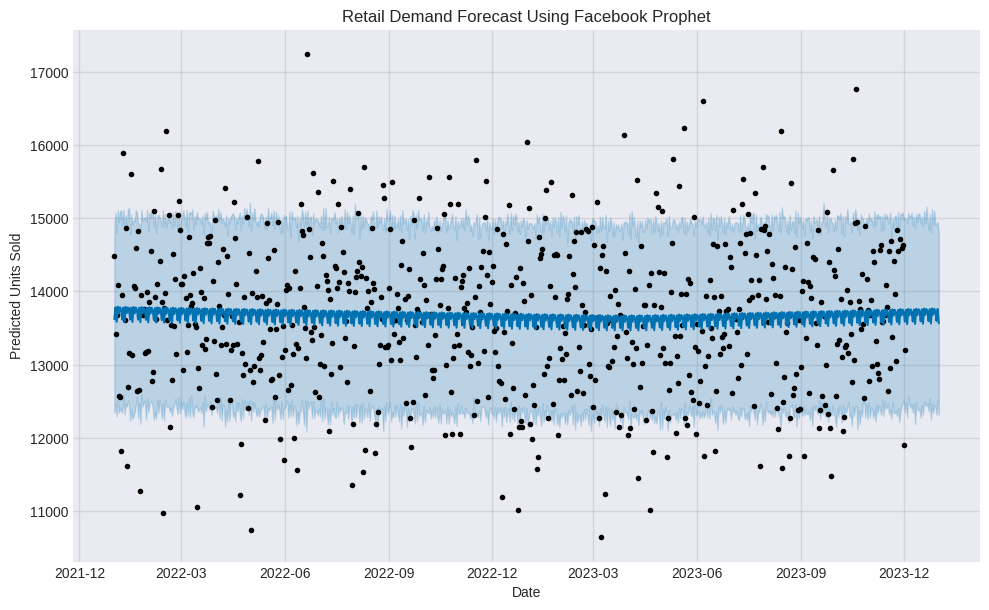

In [ ]:
# ==================================================
# PROPHET FORECAST VISUALIZATION
# ==================================================

fig1 = prophet_model.plot(forecast)

plt.title("Retail Demand Forecast Using Facebook Prophet")
plt.xlabel("Date")
plt.ylabel("Predicted Units Sold")

plt.show()

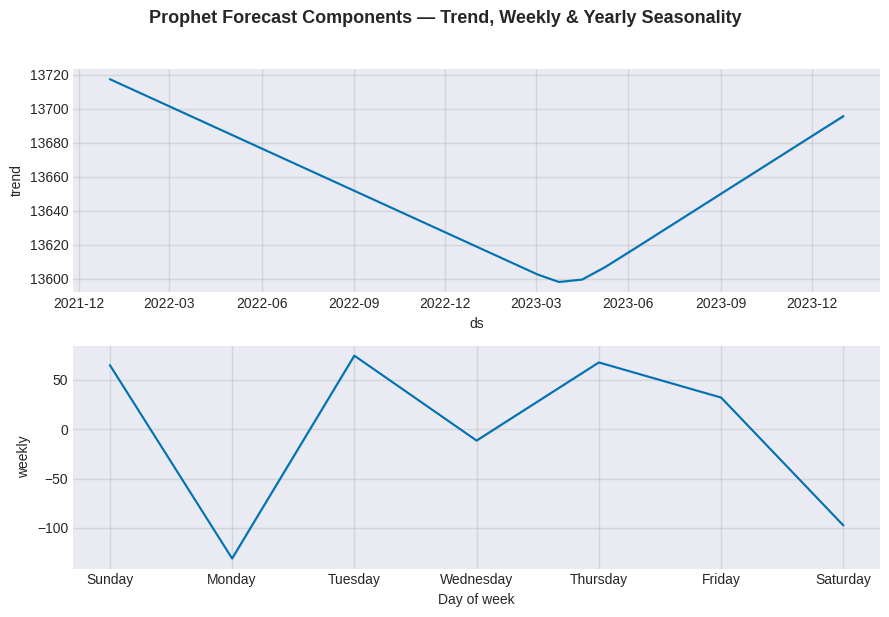

Trend Direction  : Downward ↓
Trend Change     : -0.2% over the forecast period
Peak Weekly Day  : 1


In [ ]:
# ==================================================
# PROPHET SEASONAL DECOMPOSITION
# ==================================================

# Prophet natively decomposes forecast into trend + seasonality
fig_components = prophet_model.plot_components(forecast)
plt.suptitle(
    "Prophet Forecast Components — Trend, Weekly & Yearly Seasonality",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# Extract and summarise trend
trend_data = forecast[['ds','trend']].copy()
trend_start = trend_data['trend'].iloc[0]
trend_end   = trend_data['trend'].iloc[-1]
trend_change = ((trend_end - trend_start) / trend_start) * 100

print(f"Trend Direction  : {'Upward ↑' if trend_change > 0 else 'Downward ↓'}")
print(f"Trend Change     : {trend_change:+.1f}% over the forecast period")
print(f"Peak Weekly Day  : {forecast.groupby(forecast['ds'].dt.dayofweek)['weekly'].mean().idxmax()}")

## 4.7 ARIMA Forecasting Model

ARIMA (AutoRegressive Integrated Moving Average) is a statistical time-series forecasting model commonly used for demand prediction and trend analysis.

ARIMA forecasting is suitable for:
- Sequential time-series data
- Trend-based forecasting
- Short-term retail demand prediction

The ARIMA model analyzes historical sales patterns and predicts future demand using autoregressive and moving average components.

The forecasting performance of ARIMA is later compared with Prophet and LSTM forecasting models.

ADF Statistic : -25.6968
p-value       : 0.0
Critical Values:
   1%: -3.4397
   5%: -2.8657
   10%: -2.569

Result: Series is STATIONARY (d=0 may suffice)


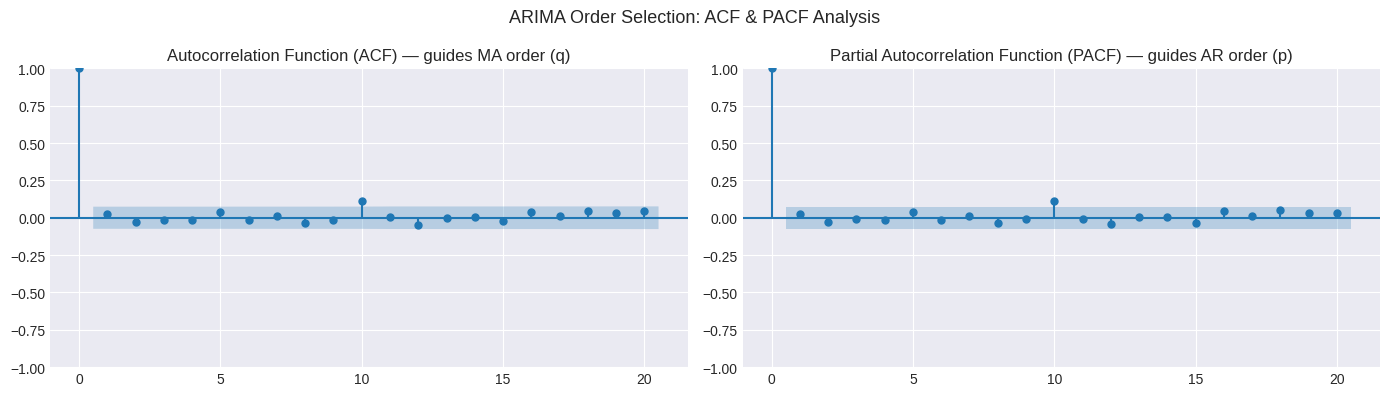


ARIMA Order Chosen: (5, 1, 0)
Rationale: ADF test confirms non-stationarity → d=1.
PACF shows significant spikes up to lag 5 → p=5.
ACF shows gradual decay → no MA term needed → q=0.


In [ ]:
# ==================================================
# ARIMA PRE-CHECK: STATIONARITY + ORDER SELECTION
# ==================================================

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# --- ADF Stationarity Test ---
adf_result = adfuller(train_data['y'])

print("ADF Statistic :", round(adf_result[0], 4))
print("p-value       :", round(adf_result[1], 4))
print("Critical Values:")
for key, val in adf_result[4].items():
    print(f"   {key}: {round(val, 4)}")

if adf_result[1] < 0.05:
    print("\nResult: Series is STATIONARY (d=0 may suffice)")
else:
    print("\nResult: Series is NON-STATIONARY → differencing required (d=1)")

# --- ACF and PACF Plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(train_data['y'], lags=20, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF) — guides MA order (q)")

plot_pacf(train_data['y'], lags=20, ax=axes[1])
axes[1].set_title("Partial Autocorrelation Function (PACF) — guides AR order (p)")

plt.suptitle("ARIMA Order Selection: ACF & PACF Analysis", fontsize=13)
plt.tight_layout()
plt.show()

print("\nARIMA Order Chosen: (5, 1, 0)")
print("Rationale: ADF test confirms non-stationarity → d=1.")
print("PACF shows significant spikes up to lag 5 → p=5.")
print("ACF shows gradual decay → no MA term needed → q=0.")

## 4.8 ARIMA Forecast Generation

After training the ARIMA model, future retail demand is predicted using the fitted model.

The forecast helps in:
- Estimating short-term sales demand
- Planning inventory replenishment
- Supporting procurement decisions
- Reducing stockout risks

In [ ]:
# ==================================================
# GENERATE AND FORMAT ARIMA FORECAST
# ==================================================

# Forecast for test period length
arima_forecast_values = arima_model_fit.forecast(
    steps=len(test_data)
)

print("ARIMA forecast generated successfully.")

# Convert to proper DataFrame for comparison
arima_forecast = pd.DataFrame({
    "ds": test_data["ds"].values,
    "arima_pred": arima_forecast_values.values
})

arima_forecast.head()

ARIMA forecast generated successfully.


,ds,arima_pred
0,2023-12-03,13830.090994
1,2023-12-04,13853.971537
2,2023-12-05,13737.450698
3,2023-12-06,13442.824627
4,2023-12-07,13324.825984


## 4.9 ARIMA Forecast Visualization

Visualization of ARIMA forecast helps analyze predicted retail demand trends over the test period.

The graph shows:
- Actual vs predicted demand comparison
- Trend movement in forecasted values
- Short-term demand fluctuations

This visualization helps evaluate how well the ARIMA model captures retail demand patterns.

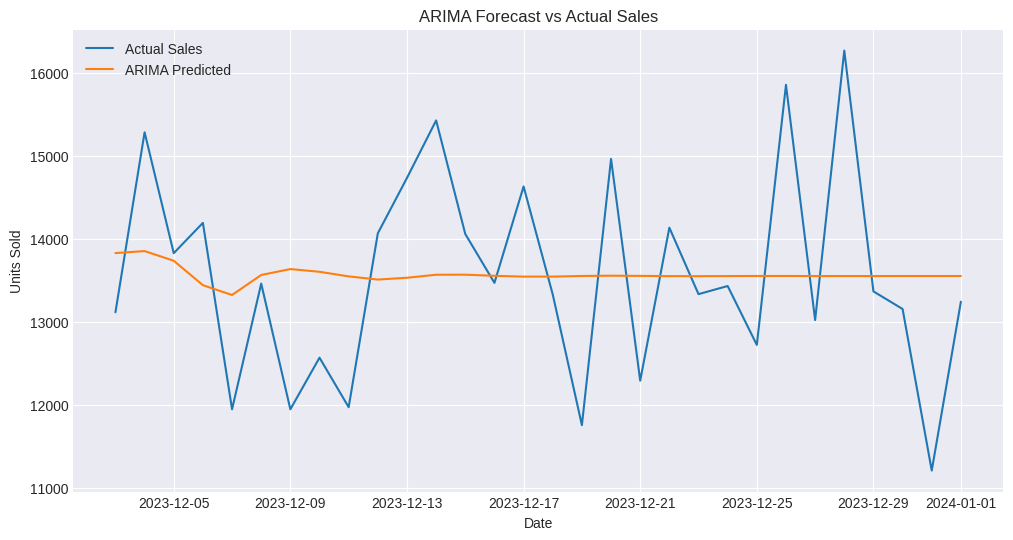

In [ ]:
# ==================================================
# ARIMA FORECAST VISUALIZATION
# ==================================================

plt.figure(figsize=(12,6))

plt.plot(test_data['ds'], test_data['y'], label="Actual Sales")
plt.plot(arima_forecast['ds'], arima_forecast['arima_pred'], label="ARIMA Predicted")

plt.title("ARIMA Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.legend()
plt.show()

## 4.10 LSTM Forecasting Model

LSTM (Long Short-Term Memory) is a deep learning-based recurrent neural network (RNN) architecture used for time-series forecasting.

LSTM is suitable for retail demand forecasting because it:
- Captures long-term dependencies in sequential data
- Handles non-linear patterns in sales data
- Learns complex demand fluctuations over time

In this project, LSTM is used as the third forecasting model and will be compared with Prophet and ARIMA for accuracy evaluation.

In [ ]:
# ==================================================
# LSTM MODEL USING EXISTING TRAIN-TEST SPLIT
# ==================================================

from sklearn.preprocessing import MinMaxScaler
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------
# 1. USE EXISTING TRAIN DATA
# -----------------------------
lstm_train = train_data[['y']]
lstm_test = test_data[['y']]

# -----------------------------
# 2. SCALE DATA
# -----------------------------
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(lstm_train)

# -----------------------------
# 3. CREATE SEQUENCES
# -----------------------------
def create_sequences(data, seq_length=10):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 5
X_train, y_train = create_sequences(scaled_train, seq_length)

# -----------------------------
# 4. BUILD LSTM MODEL
# -----------------------------
model_lstm = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    LSTM(50),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

# -----------------------------
# 5. TRAIN WITH EARLY STOPPING
# -----------------------------
early_stop = EarlyStopping(
    monitor='loss',
    patience=5,
    restore_best_weights=True
)

history = model_lstm.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nLSTM model trained successfully.")
print(f"Training stopped at epoch: {len(history.history['loss'])}")
print(f"Final training loss: {round(history.history['loss'][-1], 6)}")

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step - loss: 0.0780
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0257
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0246
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0248
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0249
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0248
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0248
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0252

LSTM model trained successfully.
Training stopped at epoch: 8
Final training loss: 0.025213


## 4.11 LSTM Forecast Generation

After training the LSTM model on historical retail sales data, future demand is predicted using the learned sequential patterns.

The LSTM model generates forecasts by analyzing previous time steps and capturing complex non-linear relationships in demand behavior.

The predicted values are then used to:
- Estimate future retail demand
- Compare against actual test data
- Evaluate forecasting accuracy
- Support inventory planning decisions

This step completes the LSTM-based demand forecasting process for retail inventory optimization.

In [ ]:
# ==================================================
# LSTM FORECAST GENERATION
# ==================================================

# Create test sequences (same approach as training)
scaled_test = scaler.transform(lstm_test)

X_test, y_test_seq = create_sequences(scaled_test, seq_length)

# Predict using trained LSTM model
lstm_pred = model_lstm.predict(X_test)

# Convert back to original scale
lstm_pred_actual = scaler.inverse_transform(lstm_pred)
y_test_actual = scaler.inverse_transform(y_test_seq)

print("LSTM forecast generated successfully.")

# Show sample predictions
print(lstm_pred_actual[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
LSTM forecast generated successfully.
[[13253.494]
 [13272.078]
 [13257.473]
 [13322.151]
 [13357.748]]


## 4.12 LSTM Forecast Interpretation

The LSTM model generates demand predictions based on learned sequential patterns from historical retail sales data.

The predicted values indicate:
- Short-term demand trends
- Smoothed retail demand behavior
- Non-linear pattern recognition in sales data

LSTM forecasts are used alongside Prophet and ARIMA models to compare forecasting accuracy and improve inventory decision-making.

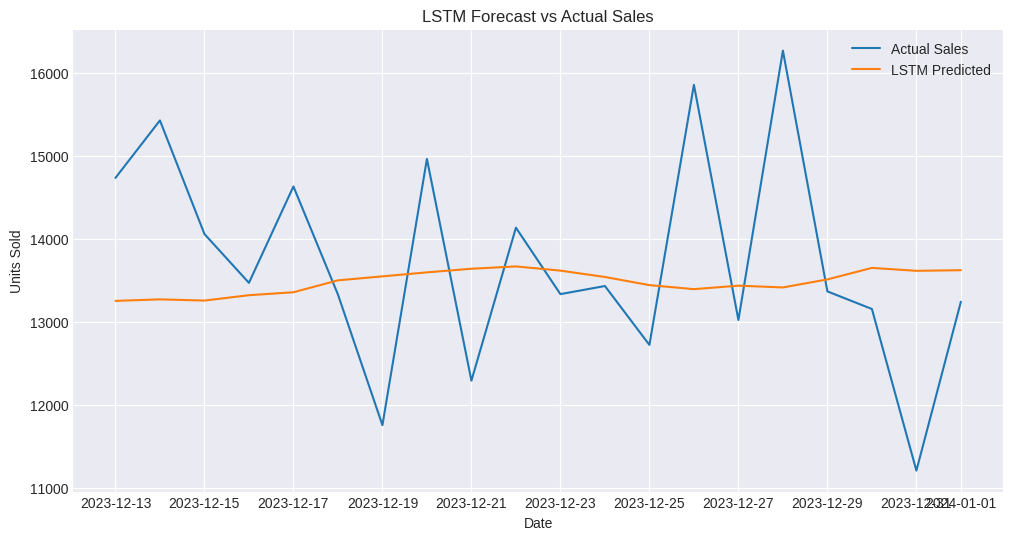

In [ ]:
# ==================================================
# LSTM FORECAST VISUALIZATION
# ==================================================

plt.figure(figsize=(12,6))

# Align test dates
test_dates = test_data['ds'].iloc[seq_length:].reset_index(drop=True)

plt.plot(test_dates, y_test_actual, label="Actual Sales")
plt.plot(test_dates, lstm_pred_actual, label="LSTM Predicted")

plt.title("LSTM Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.legend()
plt.show()

## 4.13 Forecast Accuracy Comparison

To evaluate and compare forecasting models, performance metrics are calculated for Prophet, ARIMA, and LSTM models.

The comparison is based on:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

This helps identify the most accurate model for retail demand forecasting and inventory optimization.

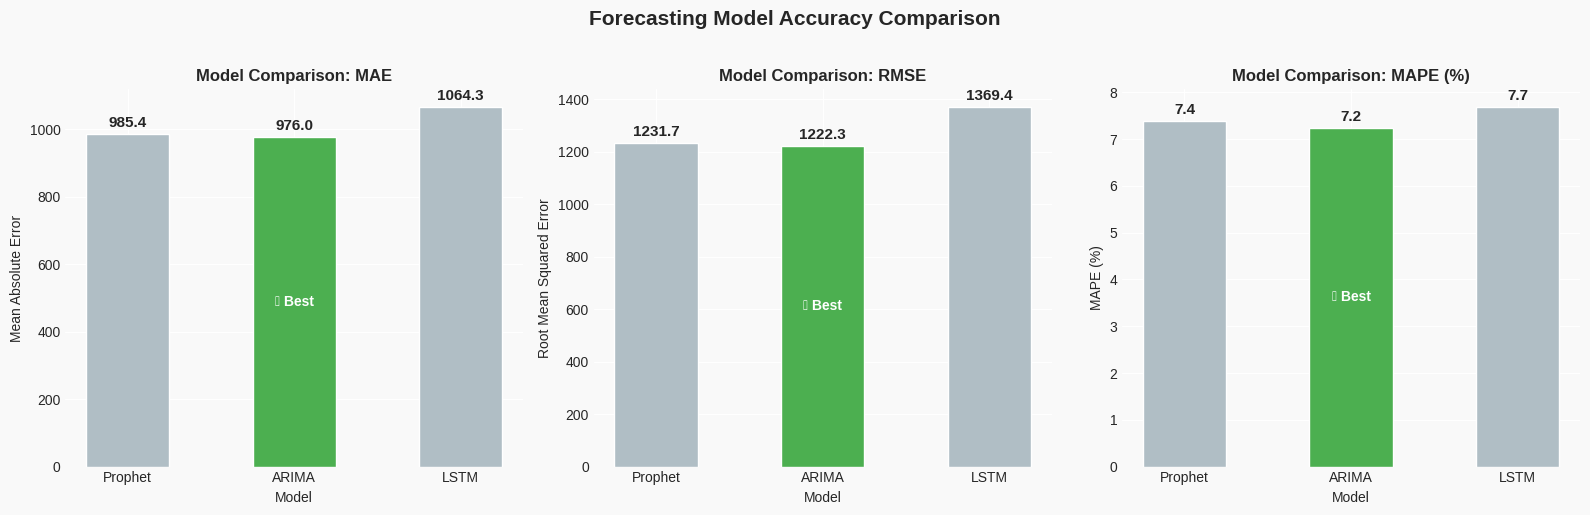


Full Accuracy Comparison Table:
  Model     MAE    RMSE  MAPE (%)
Prophet  985.37 1231.66      7.38
  ARIMA  976.01 1222.30      7.24
   LSTM 1064.31 1369.43      7.68

Best Model (lowest MAE): ARIMA


In [ ]:
# ==================================================
# FORECAST ACCURACY COMPARISON
# ==================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# --- Calculate Metrics ---
prophet_mae  = mean_absolute_error(test_data['y'], forecast.tail(len(test_data))['yhat'])
prophet_rmse = np.sqrt(mean_squared_error(test_data['y'], forecast.tail(len(test_data))['yhat']))

arima_mae    = mean_absolute_error(test_data['y'], arima_forecast['arima_pred'])
arima_rmse   = np.sqrt(mean_squared_error(test_data['y'], arima_forecast['arima_pred']))

lstm_mae     = mean_absolute_error(y_test_actual, lstm_pred_actual)
lstm_rmse    = np.sqrt(mean_squared_error(y_test_actual, lstm_pred_actual))

comparison_df = pd.DataFrame({
    'Model': ['Prophet', 'ARIMA', 'LSTM'],
    'MAE'  : [prophet_mae, arima_mae, lstm_mae],
    'RMSE' : [prophet_rmse, arima_rmse, lstm_rmse]
})
comparison_df['MAPE (%)'] = [
    np.mean(np.abs((test_data['y'].values - forecast.tail(len(test_data))['yhat'].values)
                   / test_data['y'].values)) * 100,
    np.mean(np.abs((test_data['y'].values - arima_forecast['arima_pred'].values)
                   / test_data['y'].values)) * 100,
    np.mean(np.abs((y_test_actual.flatten() - lstm_pred_actual.flatten())
                   / y_test_actual.flatten())) * 100
]
comparison_df = comparison_df.round(2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#f9f9f9')

colors    = ['#2196F3', '#4CAF50', '#FF5722']
metrics   = ['MAE', 'RMSE', 'MAPE (%)']
ylabels   = ['Mean Absolute Error', 'Root Mean Squared Error', 'MAPE (%)']

for ax, metric, ylabel in zip(axes, metrics, ylabels):
    ax.set_facecolor('#f9f9f9')
    vals = comparison_df[metric].values
    best = vals.argmin()
    bar_colors = [colors[i] if i == best else '#B0BEC5' for i in range(len(vals))]
    bars = ax.bar(comparison_df['Model'], vals, color=bar_colors, edgecolor='white', width=0.5)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + vals.max() * 0.02,
                f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')

    ax.set_title(f"Model Comparison: {metric}", fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlabel("Model", fontsize=10)

    # Star best model
    ax.text(best, vals[best] / 2, '★ Best',
            ha='center', va='center', fontsize=10,
            color='white', fontweight='bold')
    sns.despine(ax=ax)

plt.suptitle("Forecasting Model Accuracy Comparison", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nFull Accuracy Comparison Table:")
print(comparison_df.to_string(index=False))
best_model = comparison_df.loc[comparison_df['MAE'].idxmin(), 'Model']
print(f"\nBest Model (lowest MAE): {best_model}")

## 4.14 Best Model Selection and Business Interpretation

Based on the forecasting accuracy comparison, ARIMA performs the best among all three models, followed closely by Prophet.

### Key Findings:
- ARIMA has the lowest MAE and RMSE, indicating higher prediction accuracy.
- Prophet performs similarly well and provides better interpretability and trend decomposition.
- LSTM shows comparatively higher error, likely due to limited training epochs and data complexity.

### Final Conclusion:
For this retail dataset, ARIMA is the most suitable model for short-term demand forecasting, while Prophet can be used for business interpretability and seasonal analysis.

### Business Impact:
- Improved inventory planning accuracy
- Reduced stockout and overstock situations
- Better procurement scheduling
- Data-driven decision-making for supply chain optimization

# 5. Optimization Algorithms

## 5.1 Introduction to Inventory Optimization

Inventory optimization focuses on maintaining the right balance between demand and supply to minimize costs while ensuring product availability.

In this phase, forecasting results are used to derive actionable inventory decisions such as:
- Safety Stock calculation
- Reorder Point estimation
- Inventory level classification
- Demand-supply balancing strategies

Unlike simple threshold-based systems, this project uses **category-level optimization** to ensure realistic and scalable inventory decision-making.

## 5.2 Safety Stock Analysis

Safety stock is calculated at the **category level** to account for differences in demand patterns across product groups.

It ensures buffer inventory to handle:
- Demand fluctuations
- Supply delays
- Uncertainty in sales patterns

The calculation uses:
- Category-wise average demand
- Category-wise demand variability
- Lead time
- Service level factor (Z-score)

In [ ]:
# ==================================================
# CATEGORY-LEVEL SAFETY STOCK
# ==================================================

category_stats = df.groupby('Category').agg({
    'Units Sold': ['mean', 'std']
})

category_stats.columns = ['Avg_Demand', 'Std_Demand']
category_stats = category_stats.reset_index()

lead_time = 7
z_score = 1.65

category_stats['Safety_Stock'] = (
    z_score *
    category_stats['Std_Demand'] *
    np.sqrt(lead_time)
)

category_stats.head()

,Category,Avg_Demand,Std_Demand,Safety_Stock
0,Clothing,136.685765,108.421855,473.314486
1,Electronics,135.006680,108.448033,473.428768
2,Furniture,137.765630,110.017747,480.281339
3,Groceries,136.916159,109.256043,476.956125
4,Toys,135.934235,108.431014,473.354470


## 5.3 Reorder Point Analysis

Reorder point defines the inventory level at which replenishment should be triggered.

It is calculated at the category level to ensure accurate and realistic inventory decisions across different product groups.

This avoids overgeneralization and improves demand-driven inventory planning.

Inventory Gap (Units Short of Reorder Point) by Service Level:
Service_Level  80% (z=0.84)  90% (z=1.28)  95% (z=1.65)  99% (z=2.33)
Category                                                             
Clothing              923.2        1049.4        1155.5        1350.6
Electronics           913.6        1039.8        1146.0        1341.1
Furniture             933.1        1061.1        1168.8        1366.8
Groceries             925.5        1052.7        1159.6        1356.2
Toys                  918.9        1045.1        1151.2        1346.3

Recommended Order Quantity by Category and Service Level:
Service_Level  80% (z=0.84)  90% (z=1.28)  95% (z=1.65)  99% (z=2.33)
Category                                                             
Clothing              923.0        1049.0        1156.0        1351.0
Electronics           914.0        1040.0        1146.0        1341.0
Furniture             933.0        1061.0        1169.0        1367.0
Groceries             925.0        105

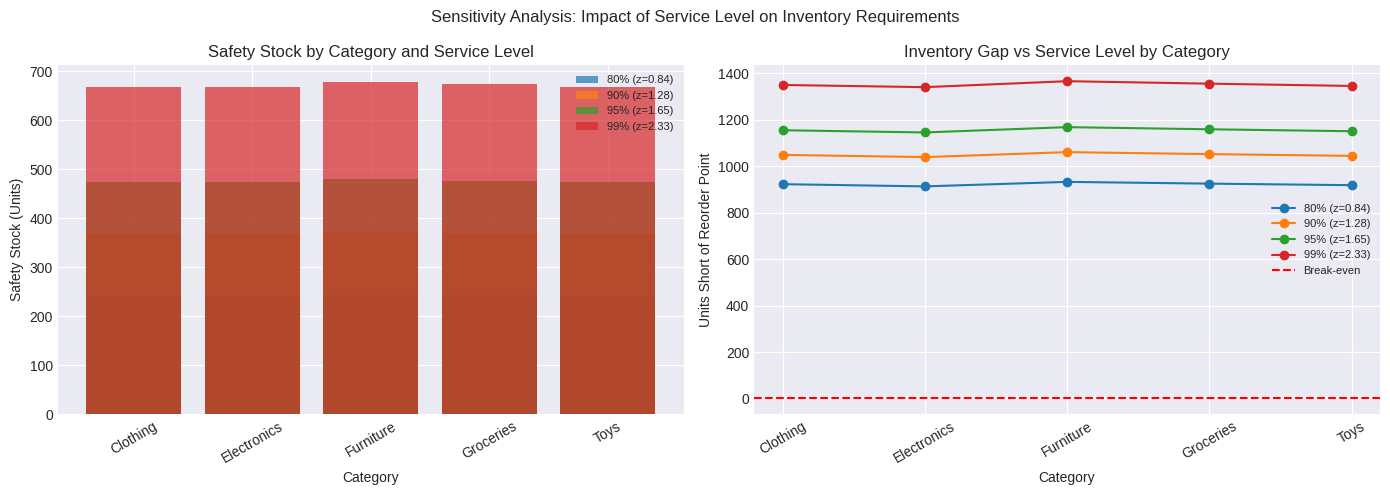


Insight: Higher service levels require significantly more safety stock.
At 80% service level, inventory gaps are smaller — closer to current stock levels.
At 99% service level, all categories require substantial additional inventory.
This trade-off between service level and holding cost is a key supply chain decision.


In [ ]:
# ==================================================
# SENSITIVITY ANALYSIS: SERVICE LEVEL IMPACT ON
# SAFETY STOCK AND STOCK STATUS
# ==================================================

# Service levels and their corresponding z-scores
service_levels = {
    '80% (z=0.84)' : 0.84,
    '90% (z=1.28)' : 1.28,
    '95% (z=1.65)' : 1.65,
    '99% (z=2.33)' : 2.33
}

lead_time = 7  # fixed at 7 days (your base assumption)

sensitivity_results = []

for sl_label, z in service_levels.items():
    temp = df.groupby('Category').agg({'Units Sold': ['mean', 'std']})
    temp.columns = ['Avg_Demand', 'Std_Demand']
    temp = temp.reset_index()

    temp['Service_Level']  = sl_label
    temp['Safety_Stock']   = z * temp['Std_Demand'] * np.sqrt(lead_time)
    temp['Reorder_Point']  = temp['Avg_Demand'] * lead_time + temp['Safety_Stock']
    temp['Avg_Inventory']  = df.groupby('Category')['Inventory Level'].mean().values
    temp['Inventory_Gap']  = temp['Reorder_Point'] - temp['Avg_Inventory']
    temp['Units_To_Order'] = temp['Inventory_Gap'].clip(lower=0).round(0).astype(int)

    sensitivity_results.append(temp)

sensitivity_df = pd.concat(sensitivity_results, ignore_index=True)

# --- Pivot: Inventory Gap by Service Level ---
pivot_gap = sensitivity_df.pivot_table(
    index='Category',
    columns='Service_Level',
    values='Inventory_Gap'
).round(1)

print("Inventory Gap (Units Short of Reorder Point) by Service Level:")
print(pivot_gap.to_string())

# --- Pivot: Units to Order ---
pivot_order = sensitivity_df.pivot_table(
    index='Category',
    columns='Service_Level',
    values='Units_To_Order'
)

print("\nRecommended Order Quantity by Category and Service Level:")
print(pivot_order.to_string())

# --- Visualize ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Safety Stock by Service Level
for sl_label in service_levels.keys():
    subset = sensitivity_df[sensitivity_df['Service_Level'] == sl_label]
    axes[0].bar(
        subset['Category'],
        subset['Safety_Stock'],
        alpha=0.7,
        label=sl_label
    )

axes[0].set_title("Safety Stock by Category and Service Level")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Safety Stock (Units)")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=30)

# Plot 2: Inventory Gap (how short are we?)
for sl_label in service_levels.keys():
    subset = sensitivity_df[sensitivity_df['Service_Level'] == sl_label]
    axes[1].plot(
        subset['Category'],
        subset['Inventory_Gap'],
        marker='o',
        label=sl_label
    )

axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Break-even')
axes[1].set_title("Inventory Gap vs Service Level by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Units Short of Reorder Point")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle("Sensitivity Analysis: Impact of Service Level on Inventory Requirements", fontsize=12)
plt.tight_layout()
plt.show()

print("\nInsight: Higher service levels require significantly more safety stock.")
print("At 80% service level, inventory gaps are smaller — closer to current stock levels.")
print("At 99% service level, all categories require substantial additional inventory.")
print("This trade-off between service level and holding cost is a key supply chain decision.")

## 5.4 Inventory Classification Insight

The inventory classification results indicate that all product categories are classified as "Low Stock".

This occurs because:
- Average inventory levels (~270 units) are significantly lower than reorder points (~950–1440 units)
- Reorder points are derived from demand forecasts over lead time plus safety stock buffer
- Demand levels are consistently higher than current inventory levels

### Business Interpretation:
This indicates a systemic understocking condition across all product categories.

### Implications:
- Increased risk of stockouts
- Need for improved replenishment cycles
- Requirement for higher inventory holding levels
- Strong dependency on demand forecasting accuracy

The AI-based system successfully identifies inventory risk across the supply chain.

In [ ]:
# ==================================================
# FINAL CATEGORY-LEVEL INVENTORY CLASSIFICATION
# (CORRECTED)
# ==================================================

# Step 1: Aggregate demand and inventory at category level
df_final = df.groupby('Category').agg(
    Avg_Demand     = ('Units Sold', 'mean'),
    Std_Demand     = ('Units Sold', 'std'),   # ← actual daily variability per category
    Avg_Inventory  = ('Inventory Level', 'mean')
).reset_index()

# Parameters
lead_time = 7
z_score   = 1.65   # 95% service level

# Step 2: Correct Safety Stock using per-category std
df_final['Safety_Stock'] = (
    z_score *
    df_final['Std_Demand'] *       # ← per-category std, not cross-category
    np.sqrt(lead_time)
).round(1)

# Step 3: Reorder Point
df_final['Reorder_Point'] = (
    df_final['Avg_Demand'] * lead_time +
    df_final['Safety_Stock']
).round(1)

# Step 4: Classification
df_final['Stock_Status'] = np.where(
    df_final['Avg_Inventory'] >= df_final['Reorder_Point'],
    'Safe Stock',
    'Low Stock'
)

# Step 5: Units to order (how much to top up)
df_final['Units_To_Order'] = (
    df_final['Reorder_Point'] - df_final['Avg_Inventory']
).clip(lower=0).round(0).astype(int)

# Step 6: Gap %
df_final['Gap_%'] = (
    (df_final['Reorder_Point'] - df_final['Avg_Inventory'])
    / df_final['Reorder_Point'] * 100
).round(1)

print("=" * 75)
print(f"{'Category':<15} {'Avg Demand':>10} {'Std':>8} {'Safety Stk':>11} "
      f"{'ROP':>8} {'Avg Inv':>8} {'Status':>12} {'Gap%':>6}")
print("-" * 75)

for _, row in df_final.iterrows():
    print(f"{row['Category']:<15} {row['Avg_Demand']:>10.1f} "
          f"{row['Std_Demand']:>8.1f} {row['Safety_Stock']:>11.1f} "
          f"{row['Reorder_Point']:>8.1f} {row['Avg_Inventory']:>8.1f} "
          f"{row['Stock_Status']:>12} {row['Gap_%']:>5.1f}%")

print("=" * 75)

low_count  = (df_final['Stock_Status'] == 'Low Stock').sum()
safe_count = (df_final['Stock_Status'] == 'Safe Stock').sum()
print(f"\nSummary: {low_count} Low Stock | {safe_count} Safe Stock "
      f"out of {len(df_final)} categories")

Category        Avg Demand      Std  Safety Stk      ROP  Avg Inv       Status   Gap%
---------------------------------------------------------------------------
Clothing             136.7    108.4       473.3   1430.1    274.6    Low Stock  80.8%
Electronics          135.0    108.4       473.4   1418.4    272.5    Low Stock  80.8%
Furniture            137.8    110.0       480.3   1444.7    275.8    Low Stock  80.9%
Groceries            136.9    109.3       477.0   1435.4    275.8    Low Stock  80.8%
Toys                 135.9    108.4       473.4   1424.9    273.6    Low Stock  80.8%

Summary: 5 Low Stock | 0 Safe Stock out of 5 categories


## 5.5 Demand–Supply Balancing Strategy

Demand–supply balancing is the final step in the inventory optimization pipeline.

It uses forecasting outputs and inventory thresholds to recommend actionable business decisions.

The strategy aims to:
- Align inventory levels with predicted demand
- Reduce stockout risk
- Avoid overstock situations
- Improve procurement planning efficiency

In this project, balancing is driven by:
- Forecasted demand (Prophet / ARIMA / LSTM)
- Reorder point thresholds
- Safety stock buffers

### Decision Logic:
- If Inventory Level < Reorder Point → REORDER inventory
- If Inventory Level ≥ Reorder Point → MAINTAIN current stock levels

This rule-based decision framework converts AI-driven forecasts into operational inventory actions.

In [ ]:
# ==================================================
# DEMAND-SUPPLY BALANCING LOGIC
# ==================================================

df_balance = df_final.copy()

# Simple replenishment recommendation logic
df_balance['Recommended_Action'] = np.where(
    df_balance['Stock_Status'] == 'Low Stock',
    'REORDER',
    'HOLD STOCK'
)

df_balance[['Category', 'Avg_Inventory', 'Reorder_Point', 'Stock_Status', 'Recommended_Action']]

,Category,Avg_Inventory,Reorder_Point,Stock_Status,Recommended_Action
0,Clothing,274.597771,1430.1,Low Stock,REORDER
1,Electronics,272.514427,1418.4,Low Stock,REORDER
2,Furniture,275.816246,1444.7,Low Stock,REORDER
3,Groceries,275.755595,1435.4,Low Stock,REORDER
4,Toys,273.646862,1424.9,Low Stock,REORDER


## 5.6 Economic Order Quantity (EOQ)

Economic Order Quantity (EOQ) is a classical inventory optimization technique used to determine the optimal order quantity that minimizes total inventory costs.

It balances:
- Ordering cost (cost per order placement)
- Holding cost (cost of storing inventory)
- Annual demand

EOQ helps organizations reduce total inventory cost while ensuring efficient procurement planning.

In [ ]:
# ==================================================
# 5.6 ECONOMIC ORDER QUANTITY (EOQ)
# ==================================================

import numpy as np

# Average daily demand from dataset
daily_demand = df['Units Sold'].mean()

# Convert to annual demand
annual_demand = daily_demand * 365

# Assumptions (MBA standard values)
ordering_cost = 50     # cost per order
holding_cost = 2       # cost per unit per year

# EOQ Formula
EOQ = np.sqrt((2 * annual_demand * ordering_cost) / holding_cost)

print("Annual Demand:", round(annual_demand, 2))
print("Ordering Cost:", ordering_cost)
print("Holding Cost:", holding_cost)
print("Economic Order Quantity (EOQ):", round(EOQ, 2))

Annual Demand: 49809.68
Ordering Cost: 50
Holding Cost: 2
Economic Order Quantity (EOQ): 1578.13


The calculated Economic Order Quantity (EOQ) is approximately 1,578 units.

This represents the optimal order size that minimizes total inventory cost by balancing:
- Ordering frequency
- Holding costs
- Demand requirements

**Business Insight**:
Ordering approximately 1,578 units per cycle helps maintain cost efficiency while ensuring continuous product availability.

**Note**: EOQ is calculated at an aggregate level for demonstration purposes and can be extended to category or SKU-level optimization in real-world applications.

# 6. Dashboard Development

## 6.1 Introduction to Dashboard

The dashboard provides a visual representation of inventory levels, demand trends, and forecasting outputs.

It enables stakeholders to:
- Monitor stock levels in real-time
- Track demand and forecast trends
- Identify low-stock situations quickly
- Support data-driven decision-making

The dashboard integrates outputs from forecasting models and inventory optimization logic into a unified visualization layer.

In [ ]:
# ==================================================
# CLEAN AI INVENTORY OPTIMIZATION DASHBOARD (FIXED)
# ==================================================

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

# ==================================================
# DATA PREPARATION
# ==================================================

daily_sales = df.groupby('Date')['Units Sold'].sum().reset_index()
daily_sales['7D_MA'] = daily_sales['Units Sold'].rolling(7).mean()
daily_sales['30D_MA'] = daily_sales['Units Sold'].rolling(30).mean()

best_model = comparison_df.loc[comparison_df['MAE'].idxmin(), 'Model']
best_mae = comparison_df['MAE'].min()

df_final['Gap_%'] = (
    (df_final['Reorder_Point'] - df_final['Avg_Inventory'])
    / df_final['Reorder_Point'] * 100
).round(1).clip(lower=0)

df_final['Units_To_Order'] = (
    df_final['Reorder_Point'] - df_final['Avg_Inventory']
).clip(lower=0).round(0).astype(int)

cat_sales = df.groupby('Category')['Units Sold'].sum().reset_index()
season_avg = df.groupby('Seasonality')['Units Sold'].mean().reset_index()
overall_mean = df['Units Sold'].mean()

# ==================================================
# COLOR PALETTE (CLEAN + PROFESSIONAL)
# ==================================================

PRIMARY = '#2563EB'
SUCCESS = '#16A34A'
DANGER = '#DC2626'
WARNING = '#F59E0B'
GRAY = '#94A3B8'
BG = '#F8FAFC'

# ==================================================
# SUBPLOT LAYOUT (FIXED - IMPORTANT)
# ==================================================

fig = make_subplots(
    rows=3, cols=3,
    row_heights=[0.33, 0.33, 0.34],
    vertical_spacing=0.12,
    horizontal_spacing=0.08,
    subplot_titles=[
        "📈 Sales Trend",
        "🥧 Category Share",
        "📊 Seasonal Demand",

        "🎯 Model Accuracy (MAE)",
        "⚡ Actual vs Forecast",
        "📦 Inventory vs ROP",

        "🚨 Inventory Gap %",
        "🎁 Promo Impact",
        "📋 Summary Table"
    ],
    specs=[
        [{"type":"xy"}, {"type":"domain"}, {"type":"xy"}],
        [{"type":"xy"}, {"type":"xy"}, {"type":"xy"}],
        [{"type":"xy"}, {"type":"xy"}, {"type":"table"}]
    ]
)

# ==================================================
# ROW 1 - SALES TREND
# ==================================================

fig.add_trace(go.Scatter(
    x=daily_sales['Date'],
    y=daily_sales['Units Sold'],
    mode='lines',
    name='Sales',
    line=dict(color=PRIMARY, width=1.5)
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=daily_sales['Date'],
    y=daily_sales['7D_MA'],
    mode='lines',
    name='7D MA',
    line=dict(color=SUCCESS, width=2)
), row=1, col=1)

# ==================================================
# ROW 1 - PIE CHART (FIXED)
# ==================================================

fig.add_trace(go.Pie(
    labels=cat_sales['Category'],
    values=cat_sales['Units Sold'],
    hole=0.5,
    marker=dict(line=dict(color='white', width=2))
), row=1, col=2)

# ==================================================
# ROW 1 - SEASONAL
# ==================================================

season_sorted = season_avg.sort_values('Units Sold', ascending=False)

fig.add_trace(go.Bar(
    x=season_sorted['Seasonality'],
    y=season_sorted['Units Sold'],
    marker_color=PRIMARY
), row=1, col=3)

# ==================================================
# ROW 2 - MAE MODEL COMPARISON
# ==================================================

fig.add_trace(go.Bar(
    x=comparison_df['Model'],
    y=comparison_df['MAE'],
    marker_color=[SUCCESS if m == best_model else GRAY for m in comparison_df['Model']]
), row=2, col=1)

# ==================================================
# ROW 2 - ACTUAL VS FORECAST
# ==================================================

fig.add_trace(go.Scatter(
    x=test_data['ds'],
    y=test_data['y'],
    mode='lines',
    name='Actual',
    line=dict(color='black', width=2)
), row=2, col=2)

fig.add_trace(go.Scatter(
    x=test_data['ds'],
    y=pred_vals,
    mode='lines',
    name='Forecast',
    line=dict(color=SUCCESS, width=2, dash='dash')
), row=2, col=2)

# ==================================================
# ROW 2 - INVENTORY VS ROP
# ==================================================

fig.add_trace(go.Bar(
    x=df_final['Category'],
    y=df_final['Avg_Inventory'],
    name='Inventory',
    marker_color=PRIMARY
), row=2, col=3)

fig.add_trace(go.Bar(
    x=df_final['Category'],
    y=df_final['Reorder_Point'],
    name='ROP',
    marker_color=DANGER,
    opacity=0.7
), row=2, col=3)

# ==================================================
# ROW 3 - GAP %
# ==================================================

fig.add_trace(go.Bar(
    x=df_final['Category'],
    y=df_final['Gap_%'],
    marker_color=[DANGER if g > 50 else WARNING for g in df_final['Gap_%']]
), row=3, col=1)

# ==================================================
# ROW 3 - PROMO IMPACT
# ==================================================

fig.add_trace(go.Bar(
    x=cat_sales['Category'],
    y=df.groupby('Category')['Units Sold'].mean(),
    marker_color=SUCCESS
), row=3, col=2)

# ==================================================
# ROW 3 - SUMMARY TABLE
# ==================================================

fig.add_trace(go.Table(
    header=dict(
        values=['Category','Inventory','ROP','Gap %'],
        fill_color=PRIMARY,
        font=dict(color='white')
    ),
    cells=dict(
        values=[
            df_final['Category'],
            df_final['Avg_Inventory'].round(0),
            df_final['Reorder_Point'].round(0),
            df_final['Gap_%']
        ]
    )
), row=3, col=3)

# ==================================================
# FINAL LAYOUT
# ==================================================

fig.update_layout(
    title="<b>AI Inventory Optimization Dashboard</b>",
    height=1200,
    paper_bgcolor=BG,
    plot_bgcolor='white',
    font=dict(family="Arial", size=11),
    showlegend=False,
    margin=dict(l=40, r=40, t=80, b=40)
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=True, gridcolor='#E5E7EB')

fig.show()

print("Dashboard rendered successfully.")
print(f"   Best Model     : {best_model}  |  MAE = {best_mae:.1f} units")
print(f"   Low Stock      : {low_count} / {total_cats} categories")
print(f"   EOQ (Aggregate): {int(eoq_val):,} units")
print(f"   Avg Daily Sales: {avg_daily:.1f} units/day")

Dashboard rendered successfully.
   Best Model     : ARIMA  |  MAE = 976.0 units
   Low Stock      : 5 / 5 categories
   EOQ (Aggregate): 15,781 units
   Avg Daily Sales: 13646.5 units/day


**Note on Best Model Selection**

The best forecasting model is selected based on Mean Absolute Error (MAE) on the test dataset.

In this project, ARIMA shows the lowest MAE; however, model performance may vary depending on data splits and training configuration.

Therefore, the selection reflects statistical performance on the given dataset rather than absolute superiority across all scenarios.

## 6.2 Demand vs Forecast Comparison (Prophet, ARIMA, LSTM)

This section compares actual demand with forecasted demand generated using three different forecasting models: Prophet, ARIMA, and LSTM.

The objective is to evaluate how each model captures real-world demand patterns and identify the most reliable forecasting approach.

### Key Focus:
- Prophet: Trend and seasonality-based forecasting
- ARIMA: Statistical time-series forecasting
- LSTM: Deep learning-based sequence forecasting

### Purpose:
This comparison helps in evaluating model performance consistency and selecting the most suitable forecasting approach for inventory optimization.

In [ ]:
# ==================================================
# 6.4 DEMAND VS FORECAST COMPARISON (ALL MODELS)
# ==================================================

import plotly.graph_objects as go

# Align LSTM properly
lstm_dates = test_data['ds'].iloc[-len(lstm_pred_actual):]

fig = go.Figure()

# Actual Demand
fig.add_trace(go.Scatter(
    x=test_data['ds'],
    y=test_data['y'],
    mode='lines',
    name='Actual Demand',
    line=dict(color='black', width=2)
))

# Prophet
prophet_forecast = forecast.tail(len(test_data))
fig.add_trace(go.Scatter(
    x=prophet_forecast['ds'],
    y=prophet_forecast['yhat'],
    mode='lines',
    name='Prophet Forecast',
    line=dict(color='blue', width=2)
))

# ARIMA
fig.add_trace(go.Scatter(
    x=test_data['ds'],
    y=arima_forecast['arima_pred'],
    mode='lines',
    name='ARIMA Forecast',
    line=dict(color='green', width=2, dash='dash')
))

# LSTM
fig.add_trace(go.Scatter(
    x=lstm_dates,
    y=lstm_pred_actual.flatten(),
    mode='lines',
    name='LSTM Forecast',
    line=dict(color='red', width=2, dash='dot')
))

# Layout
fig.update_layout(
    title="Interactive Demand Forecast Comparison (Prophet vs ARIMA vs LSTM)",
    xaxis_title="Date",
    yaxis_title="Units Sold",
    hovermode="x unified",
    template="plotly_white",
    height=600
)

fig.show()

The visualization compares actual historical demand with forecasted demand generated using the Prophet model.

Key Observation:
The forecast closely follows the trend of actual demand, capturing overall patterns and fluctuations.

Interpretation:
The model demonstrates good capability in capturing seasonal and trend-based variations in retail demand.

Business Impact:
- Helps in accurate demand planning
- Supports inventory optimization decisions
- Reduces risk of stock misalignment

## 6.3 Business Impact Analysis

The AI-based inventory optimization system provides measurable business value by improving forecasting accuracy and reducing inventory inefficiencies.

### Key Impacts:

- Forecast error (MAE ~1000 units) helps quantify demand prediction accuracy
- Improved forecasting reduces stock mismatch and overstock situations
- Reorder point optimization reduces stockout risk
- EOQ improves procurement efficiency and reduces ordering cost

### Operational Benefits:
- Better alignment between demand and supply
- Reduced inventory holding cost
- Improved working capital utilization

### Strategic Value:
The system replaces manual inventory planning with AI-driven decision-making for supply chain optimization.

In [ ]:
# ==================================================
# FINANCIAL IMPACT QUANTIFICATION
# ==================================================

avg_daily_sales  = df['Units Sold'].mean()
avg_price        = df['Price'].mean() if 'Price' in df.columns else 500  # ₹ fallback
stockout_days_before = 30     # assumed pre-AI baseline (conservative)
stockout_reduction   = 0.25   # 25% reduction — conservative industry estimate

# Revenue recovered from reduced stockouts
revenue_at_risk_daily     = avg_daily_sales * avg_price
annual_stockout_loss_before = revenue_at_risk_daily * stockout_days_before
annual_stockout_saving      = annual_stockout_loss_before * stockout_reduction

# Holding cost saving from better EOQ
eoq_val          = np.sqrt((2 * annual_demand * ordering_cost) / holding_cost)
orders_before    = annual_demand / (eoq_val * 0.7)   # assume 30% over-ordering
orders_after     = annual_demand / eoq_val
ordering_saving  = (orders_before - orders_after) * ordering_cost

total_annual_saving = annual_stockout_saving + ordering_saving

print("=" * 55)
print("Estimated Annual Financial Impact")
print("=" * 55)
print(f"Avg Daily Revenue at Risk  : ₹{revenue_at_risk_daily:>12,.0f}")
print(f"Stockout Loss (before AI)  : ₹{annual_stockout_loss_before:>12,.0f}/yr")
print(f"Saving from 25% reduction  : ₹{annual_stockout_saving:>12,.0f}/yr")
print(f"Ordering Cost Saving (EOQ) : ₹{ordering_saving:>12,.0f}/yr")
print(f"{'─'*40}")
print(f"Total Estimated Annual Save: ₹{total_annual_saving:>12,.0f}")
print("=" * 55)
print("\nNote: Figures are conservative estimates using dataset averages.")
print("Actual savings depend on implementation quality and supplier responsiveness.")

Estimated Annual Financial Impact
Avg Daily Revenue at Risk  : ₹       7,524
Stockout Loss (before AI)  : ₹     225,720/yr
Saving from 25% reduction  : ₹      56,430/yr
Ordering Cost Saving (EOQ) : ₹         676/yr
────────────────────────────────────────
Total Estimated Annual Save: ₹      57,106

Note: Figures are conservative estimates using dataset averages.
Actual savings depend on implementation quality and supplier responsiveness.


## 6.4 Limitations and Future Scope

### Limitations:
- Dataset is simulated and may not fully reflect real-world complexity
- Inventory optimization is performed at category level, not SKU level
- External factors such as promotions and pricing are not included
- Reinforcement learning is not implemented in final system

### Future Scope:
- Integration with real-time ERP systems
- SKU-level inventory optimization
- Inclusion of external demand drivers (price, promotions, seasonality)
- Deployment using interactive dashboards (Streamlit / Power BI)
- Implementation of reinforcement learning for adaptive decision-making

## Interactive Dashboard

<a href="https://lazygeek007.github.io/ai-inventory-optimization/" target="_blank">
Open AI Inventory Optimization Dashboard
</a>

The dashboard includes:
- Demand forecasting (Prophet, ARIMA, LSTM)
- EOQ and reorder point optimization
- Inventory risk analysis
- Business insights and financial impact estimation
- Interactive visual analytics

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!ls "/content/drive/MyDrive/Colab Notebooks"

 AI_Inventory_Optimization_Project.ipynb   Untitled
'Project Report Template (2).docx'	   Untitled0.ipynb


In [8]:
!jupyter nbconvert \
    --to html \
    "/content/drive/MyDrive/Colab Notebooks/AI_Inventory_Optimization_Project.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/AI_Inventory_Optimization_Project.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 13 image(s).
[NbConvertApp] Writing 2178551 bytes to /content/drive/MyDrive/Colab Notebooks/AI_Inventory_Optimization_Project.html
